# Balanced sentiment experiment

Этот notebook полностью самодостаточный для Google Colab: папки `src`, `tests` и `analysis` загружать не нужно. Внутри есть весь код baseline, lexicon, ensemble, сценарии, графики и JSON-отчёт по тестам.

Основная идея: baseline считает тональность по словам и поэтому зависит от длины отзывов. Lexicon и ensemble сначала классифицируют каждый отзыв отдельно, потом считают распределение по количеству отзывов.

## Установка зависимостей

В Colab обычно уже есть `pandas` и `matplotlib`; `openpyxl` нужен для Excel, `openai` нужен только если включать Groq LLM.

In [14]:
import importlib.util
import subprocess
import sys

for package, import_name in [("openpyxl", "openpyxl"), ("openai", "openai")]:
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

## Импорты

In [15]:
import json
import math
import os
import re
from collections import Counter
from pathlib import Path

import pandas as pd

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None

## Lexicon approach

Review-level лексикон: один отзыв получает один label, затем распределение считается по отзывам.

In [16]:
LABELS = ("positive", "negative", "neutral")

POSITIVE_PATTERNS = (
    "отлич",
    "хорош",
    "понят",
    "интерес",
    "полез",
    "крут",
    "кайф",
    "спасиб",
    "респект",
    "нрав",
    "удоб",
    "структур",
    "легк",
    "ясн",
    "люблю",
    "помог",
    "адекват",
    "зачет",
    "плюс",
    "good",
    "great",
    "excellent",
    "useful",
    "clear",
    "interesting",
    "like",
    "liked",
    "love",
    "perfect",
    "helpful",
    "thanks",
)

NEGATIVE_PATTERNS = (
    "плох",
    "ужас",
    "непонят",
    "сложн",
    "тяжел",
    "перегруж",
    "опазд",
    "неудоб",
    "бесполез",
    "бред",
    "спам",
    "флуд",
    "странн",
    "проблем",
    "минус",
    "скуч",
    "хаос",
    "ошиб",
    "душн",
    "болезн",
    "убива",
    "bad",
    "awful",
    "terrible",
    "useless",
    "hard",
    "confusing",
    "boring",
    "problem",
    "difficult",
    "unclear",
    "overloaded",
    "late",
)

NEGATIONS = {"не", "ни", "нет", "not", "no", "never", "pas", "nunca"}
NEUTRAL_PATTERNS = {"обычный", "обычно", "норм", "нейтрально", "средне", "без", "комментариев", "ok", "okay"}
POSITIVE_EMOJIS = {"🙂", "😊", "😀", "😁", "😍", "👍", "❤", "❤️", ":)", ":-)"}
NEGATIVE_EMOJIS = {"😞", "😢", "😭", "👎", "💩", ":(", ":-("}


def tokenize(text):
    return re.findall(r"[a-zа-яё]+", str(text).lower())


def rating_score(text):
    match = re.search(r"(\d+(?:[.,]\d+)?)\s*/\s*(\d+(?:[.,]\d+)?)", str(text))
    if not match:
        return None
    value = float(match.group(1).replace(",", "."))
    maximum = float(match.group(2).replace(",", "."))
    if maximum <= 0:
        return None
    ratio = value / maximum
    if ratio >= 0.75:
        return 1.0
    if ratio <= 0.4:
        return -1.0
    return 0.0


def emoji_score(text):
    value = str(text).strip()
    if value in POSITIVE_EMOJIS:
        return 1.0
    if value in NEGATIVE_EMOJIS:
        return -1.0
    return None


def is_valid_review(text):
    if rating_score(text) is not None:
        return True
    if emoji_score(text) is not None:
        return True
    tokens = tokenize(text)
    if not tokens:
        return False
    if len(tokens) == 1 and len(tokens[0]) <= 1:
        return False
    return True


def token_polarity(token):
    for pattern in NEGATIVE_PATTERNS:
        if pattern in token:
            return -1
    for pattern in POSITIVE_PATTERNS:
        if pattern in token:
            return 1
    return 0


def review_score(text):
    rating = rating_score(text)
    if rating is not None:
        return rating
    emoji = emoji_score(text)
    if emoji is not None:
        return emoji
    tokens = tokenize(text)
    score = 0
    hits = 0
    for i, token in enumerate(tokens):
        polarity = token_polarity(token)
        if polarity == 0:
            continue
        if i > 0 and tokens[i - 1] in NEGATIONS:
            polarity *= -1
        score += polarity
        hits += 1
    if hits == 0:
        return 0.0
    return score / math.sqrt(hits)


def classify_review(text, threshold=0.75):
    if not is_valid_review(text):
        return None
    score = review_score(text)
    if abs(score) < threshold:
        return "neutral"
    if score > 0:
        return "positive"
    return "negative"


def rounded_distribution(counts):
    total = sum(counts.values())
    if total == 0:
        return {label: 0.0 for label in LABELS}
    raw = {label: counts.get(label, 0) * 100 / total for label in LABELS}
    rounded = {label: round(value, 1) for label, value in raw.items()}
    diff = round(100.0 - sum(rounded.values()), 1)
    if diff:
        biggest = max(LABELS, key=lambda x: rounded[x])
        rounded[biggest] = round(rounded[biggest] + diff, 1)
    return rounded


def improved_distribution(reviews):
    labels = [classify_review(review) for review in reviews]
    labels = [label for label in labels if label is not None]
    counts = Counter(labels)
    return rounded_distribution(counts), {label: counts.get(label, 0) for label in LABELS}


def analyze_reviews(reviews):
    reviews = list(reviews)
    distribution, label_counts = improved_distribution(reviews)
    valid_count = sum(1 for review in reviews if is_valid_review(review))
    return {
        "review_count": valid_count,
        "distribution": distribution,
        "label_counts": label_counts,
    }

## Baseline approach

Baseline считает sentiment-сигналы по всем словам. Это специально проблемный подход для демонстрации перекоса по длине текста.

In [17]:
def baseline_distribution(reviews, threshold=0.05):
    counts = Counter()
    for review in reviews:
        if not is_valid_review(review):
            continue
        tokens = tokenize(review)
        for i, token in enumerate(tokens):
            polarity = token_polarity(token)
            if polarity == 0:
                continue
            if i > 0 and tokens[i - 1] in NEGATIONS:
                polarity *= -1
            if polarity > 0:
                counts["positive"] += 1
            elif polarity < 0:
                counts["negative"] += 1
        if not any(token_polarity(token) for token in tokens):
            counts["neutral"] += 1
    total = sum(counts.values())
    if total == 0:
        return {label: 0.0 for label in LABELS}
    return rounded_distribution(counts)


def analyze_reviews_baseline(reviews):
    reviews = list(reviews)
    valid_count = sum(1 for review in reviews if is_valid_review(review))
    return {
        "review_count": valid_count,
        "distribution": baseline_distribution(reviews),
    }

## Ensemble: lexicon + Groq LLM

Ensemble сначала использует лексикон. Groq LLM вызывается только для сложных случаев и только если передан client. Без ключа всё работает через fallback.

In [18]:
DEFAULT_LLM_MODEL = "llama-3.1-8b-instant"
GROQ_BASE_URL = "https://api.groq.com/openai/v1"
MIXED_MARKERS = {"но", "однако", "зато", "but", "however", "although", "though"}
SARCASM_MARKERS = {"ага", "конечно", "ну да", "as if", "yeah right"}
CONFIDENT_SCORE = 1.2
LONG_REVIEW_WORDS = 80
MIN_LLM_CONFIDENCE = 0.6


def create_groq_client(api_key=None):
    from openai import OpenAI

    api_key = api_key or os.environ.get("GROQ_API_KEY")
    if not api_key:
        raise RuntimeError("Set GROQ_API_KEY before running Groq LLM")
    return OpenAI(api_key=api_key, base_url=GROQ_BASE_URL)


def has_mixed_markers(text):
    tokens = set(tokenize(text))
    lowered = str(text).lower()
    return bool(tokens & MIXED_MARKERS) or any(marker in lowered for marker in MIXED_MARKERS)


def has_sarcasm_markers(text):
    lowered = str(text).lower()
    quoted_praise = bool(re.search(r"[\"'«“](отлич|хорош|great|good|perfect)", lowered))
    return quoted_praise or any(marker in lowered for marker in SARCASM_MARKERS)


def has_both_sentiment_sides(text):
    positives = 0
    negatives = 0
    for token in tokenize(text):
        polarity = token_polarity(token)
        if polarity > 0:
            positives += 1
        elif polarity < 0:
            negatives += 1
    return positives > 0 and negatives > 0


def is_english_review(text):
    tokens = tokenize(text)
    if not tokens:
        return False
    latin = sum(1 for token in tokens if re.search(r"[a-z]", token))
    return latin / len(tokens) >= 0.5


def needs_llm_review(text, score=None):
    if not is_valid_review(text):
        return False
    if score is None:
        score = review_score(text)
    tokens = tokenize(text)
    if abs(score) < CONFIDENT_SCORE:
        return True
    if has_mixed_markers(text):
        return True
    if has_both_sentiment_sides(text):
        return True
    if len(tokens) > LONG_REVIEW_WORDS:
        return True
    if is_english_review(text):
        return True
    if has_sarcasm_markers(text):
        return True
    return False


def build_ensemble_llm_messages(review, lexicon_label, score):
    system_prompt = (
        "You are a careful sentiment reviewer for student feedback about courses and teachers. "
        "You receive one review plus a simple lexicon prediction. Your job is to check cases "
        "where the lexicon may fail: sarcasm, mixed pros and cons, weak sentiment, English text, "
        "or long nuanced reviews. Return only JSON with keys label, confidence, and flags. "
        "Allowed labels are positive, negative, neutral. Use neutral for mixed or balanced reviews. "
        "If uncertain, choose neutral."
    )
    examples = [
        ("Отличный курс, всё понятно", "positive", 1.5, {"label": "positive", "confidence": 0.95, "flags": []}),
        ("Курс ужасный, непонятный и плохо организованный", "negative", -1.7, {"label": "negative", "confidence": 0.95, "flags": []}),
        ("Лекции интересные, но домашка слишком тяжёлая", "neutral", 0.0, {"label": "neutral", "confidence": 0.85, "flags": ["mixed"]}),
        ("Ну да, конечно, 'отличная' организация: дедлайны менялись каждый день", "positive", 1.0, {"label": "negative", "confidence": 0.8, "flags": ["sarcasm"]}),
        ("Not bad, the lectures were useful", "positive", 1.0, {"label": "positive", "confidence": 0.9, "flags": ["english"]}),
        ("The lectures were clear and useful, but the workload was too heavy and deadlines were confusing.", "neutral", 0.0, {"label": "neutral", "confidence": 0.8, "flags": ["mixed", "english"]}),
    ]
    messages = [{"role": "system", "content": system_prompt}]
    for text, label, example_score, answer in examples:
        messages.append({"role": "user", "content": f"Review:\n{text}\n\nLexicon label: {label}\nLexicon score: {example_score:.3f}"})
        messages.append({"role": "assistant", "content": json.dumps(answer)})
    messages.append({"role": "user", "content": f"Review:\n{review}\n\nLexicon label: {lexicon_label}\nLexicon score: {score:.3f}"})
    return messages


def parse_ensemble_llm_result(text):
    try:
        data = json.loads(str(text))
    except json.JSONDecodeError:
        return None
    label = str(data.get("label", "")).lower().strip()
    if label not in LABELS:
        return None
    try:
        confidence = float(data.get("confidence", 0.0))
    except (TypeError, ValueError):
        confidence = 0.0
    flags = data.get("flags", [])
    if not isinstance(flags, list):
        flags = []
    return {"label": label, "confidence": confidence, "flags": flags}


def classify_review_ensemble(review, client=None, model=DEFAULT_LLM_MODEL):
    if not is_valid_review(review):
        return None, {"source": "ignored", "llm_used": False, "fallback": False}
    score = review_score(review)
    lexicon_label = classify_review(review)
    should_use_llm = needs_llm_review(review, score)
    if not should_use_llm:
        return lexicon_label, {"source": "lexicon", "llm_used": False, "fallback": False}
    if client is None:
        return lexicon_label, {"source": "lexicon_fallback", "llm_used": False, "fallback": True}
    try:
        response = client.chat.completions.create(
            model=model,
            messages=build_ensemble_llm_messages(review, lexicon_label, score),
            temperature=0,
            top_p=1,
            max_tokens=60,
            response_format={"type": "json_object"},
        )
        content = response.choices[0].message.content
        parsed = parse_ensemble_llm_result(content)
        if parsed is not None:
            if parsed["confidence"] >= MIN_LLM_CONFIDENCE:
                return parsed["label"], {"source": "llm", "llm_used": True, "fallback": False}
            return "neutral", {"source": "llm_low_confidence", "llm_used": True, "fallback": False}
    except Exception:
        pass
    return lexicon_label, {"source": "lexicon_fallback", "llm_used": False, "fallback": True}


def ensemble_distribution(reviews, client=None, model=DEFAULT_LLM_MODEL):
    counts = Counter()
    llm_used = 0
    fallback_count = 0
    for review in reviews:
        label, meta = classify_review_ensemble(review, client=client, model=model)
        if label in LABELS:
            counts[label] += 1
        if meta.get("llm_used"):
            llm_used += 1
        if meta.get("fallback"):
            fallback_count += 1
    return {
        "method": "lexicon first, LLM for uncertain reviews",
        "distribution": rounded_distribution(counts),
        "label_counts": {label: counts.get(label, 0) for label in LABELS},
        "llm_used": llm_used,
        "fallback_count": fallback_count,
    }


def analyze_reviews_ensemble(reviews, client=None, model=DEFAULT_LLM_MODEL):
    return ensemble_distribution(list(reviews), client=client, model=model)

## Данные из Excel

Загрузите `SOP_LVL2_2026-04-20.xlsx` в Colab во временное хранилище `/content`. Если файла нет, notebook всё равно выполнит синтетические сценарии.

In [19]:
excel_candidates = list(Path('/content').glob('*.xlsx')) + [Path('/Users/grigory/Downloads/SOP_LVL2_2026-04-20.xlsx')]
excel_path = next((path for path in excel_candidates if path.exists()), None)

if excel_path is None:
    print('Excel-файл не найден. Синтетические сценарии ниже работают без него.')
else:
    workbook = pd.ExcelFile(excel_path)
    df = None
    sheet_name = None
    for candidate_sheet in workbook.sheet_names:
        candidate = pd.read_excel(excel_path, sheet_name=candidate_sheet)
        if 'Комментарий студента' in candidate.columns:
            df = candidate
            sheet_name = candidate_sheet
            break
    if df is None:
        print('Колонка Комментарий студента не найдена. Синтетические сценарии ниже работают без Excel.')
        print(f'Листы: {workbook.sheet_names}')
    else:
        comments = df['Комментарий студента'].dropna().astype(str)
        lengths = comments.str.split().str.len()
        print(f'Файл: {excel_path}')
        print(f'Лист: {sheet_name}')
        print(f'Комментариев: {len(comments)}')
        print(f'Длина отзывов: от {lengths.min()} до {lengths.max()} слов')
        display(df[['Комментарий студента']].head())

Файл: /content/SOP_LVL2_2026-04-20.xlsx
Лист: Комментарии
Комментариев: 422
Длина отзывов: от 1 до 275 слов


,Комментарий студента
0,"возможно, стоит передвинуть его на 1 курс, чт..."
1,"""Обучение по образовательной программе включае..."
2,1. Ужасная организация всего курса в чате теле...
3,Альбатша не может нормально объяснить требован...
4,Бесполезный курс.


## Сценарии и сравнение подходов

In [20]:
def make_scenarios():
    positive_short = "Отличный курс, все понятно и полезно"
    negative_long = (
        "Курс ужасный непонятный сложный тяжелый перегруженный неудобный "
        "скучный плохой проблемный "
    ) * 8
    neutral = "Обычный курс без сильных плюсов и минусов"
    positive_equal = "Отличный понятный полезный интересный удобный курс"
    negative_equal = "Плохой непонятный тяжелый скучный неудобный курс"
    mixed_long = (
        "Лекции интересные и преподаватель объясняет понятно, но домашние задания "
        "тяжелые, дедлайны неудобные, а организация местами непонятная. "
    ) * 6
    return {
        "A: 45 positive / 45 negative / 10 neutral, negative is longer": [positive_short] * 45 + [negative_long] * 45 + [neutral] * 10,
        "B: 60 positive / 25 negative / 15 neutral, equal length": [positive_equal] * 60 + [negative_equal] * 25 + [neutral] * 15,
        "C: long mixed + neutral": [mixed_long] * 20 + [neutral] * 20,
    }


def compare_reviews(reviews, scenario="custom", client=None):
    baseline = baseline_distribution(reviews)
    lexicon_distribution, lexicon_counts = improved_distribution(reviews)
    ensemble = analyze_reviews_ensemble(reviews, client=client)
    rows = [
        {
            "scenario": scenario,
            "approach": "baseline",
            "positive": baseline["positive"],
            "negative": baseline["negative"],
            "neutral": baseline["neutral"],
            "positive_count": None,
            "negative_count": None,
            "neutral_count": None,
            "llm_used": 0,
            "fallback_count": 0,
        },
        {
            "scenario": scenario,
            "approach": "lexicon",
            "positive": lexicon_distribution["positive"],
            "negative": lexicon_distribution["negative"],
            "neutral": lexicon_distribution["neutral"],
            "positive_count": lexicon_counts["positive"],
            "negative_count": lexicon_counts["negative"],
            "neutral_count": lexicon_counts["neutral"],
            "llm_used": 0,
            "fallback_count": 0,
        },
        {
            "scenario": scenario,
            "approach": "ensemble",
            "positive": ensemble["distribution"]["positive"],
            "negative": ensemble["distribution"]["negative"],
            "neutral": ensemble["distribution"]["neutral"],
            "positive_count": ensemble["label_counts"]["positive"],
            "negative_count": ensemble["label_counts"]["negative"],
            "neutral_count": ensemble["label_counts"]["neutral"],
            "llm_used": ensemble["llm_used"],
            "fallback_count": ensemble["fallback_count"],
        },
    ]
    return pd.DataFrame(rows)


def compare_scenarios(client=None):
    frames = []
    for scenario, reviews in make_scenarios().items():
        frames.append(compare_reviews(reviews, scenario=scenario, client=client))
    return pd.concat(frames, ignore_index=True)


def make_sensitivity_table(client=None):
    positive = "Отличный курс, все понятно и полезно"
    neutral = "Обычный курс без сильных плюсов и минусов"
    rows = []
    for multiplier in [1, 2, 4, 8, 12]:
        negative = (
            "Курс ужасный непонятный сложный тяжелый перегруженный неудобный "
            "скучный плохой проблемный "
        ) * multiplier
        reviews = [positive] * 45 + [negative] * 45 + [neutral] * 10
        table = compare_reviews(reviews, scenario=f"negative length x{multiplier}", client=client)
        table.insert(1, "negative_length_multiplier", multiplier)
        rows.append(table)
    return pd.concat(rows, ignore_index=True)

## Таблица comparison

In [21]:
comparison = compare_scenarios(client=None)
display(comparison)

,scenario,approach,positive,negative,neutral,positive_count,negative_count,neutral_count,llm_used,fallback_count
0,"A: 45 positive / 45 negative / 10 neutral, neg...",baseline,4.3,95.7,0.0,NaN,NaN,NaN,0,0
1,"A: 45 positive / 45 negative / 10 neutral, neg...",lexicon,45.0,45.0,10.0,45.0,45.0,10.0,0,0
2,"A: 45 positive / 45 negative / 10 neutral, neg...",ensemble,45.0,45.0,10.0,45.0,45.0,10.0,0,55
3,"B: 60 positive / 25 negative / 15 neutral, equ...",baseline,69.2,30.8,0.0,NaN,NaN,NaN,0,0
4,"B: 60 positive / 25 negative / 15 neutral, equ...",lexicon,60.0,25.0,15.0,60.0,25.0,15.0,0,0
5,"B: 60 positive / 25 negative / 15 neutral, equ...",ensemble,60.0,25.0,15.0,60.0,25.0,15.0,0,15
6,C: long mixed + neutral,baseline,50.0,50.0,0.0,NaN,NaN,NaN,0,0
7,C: long mixed + neutral,lexicon,0.0,0.0,100.0,0.0,0.0,40.0,0,0
8,C: long mixed + neutral,ensemble,0.0,0.0,100.0,0.0,0.0,40.0,0,40


## Графики comparison

Старый график был нечитаемым, потому что все сценарии и методы попадали на одну длинную ось X. Здесь графики строятся отдельно по каждому сценарию: по оси X только `baseline / lexicon / ensemble`, а длинное описание сценария вынесено в заголовок.


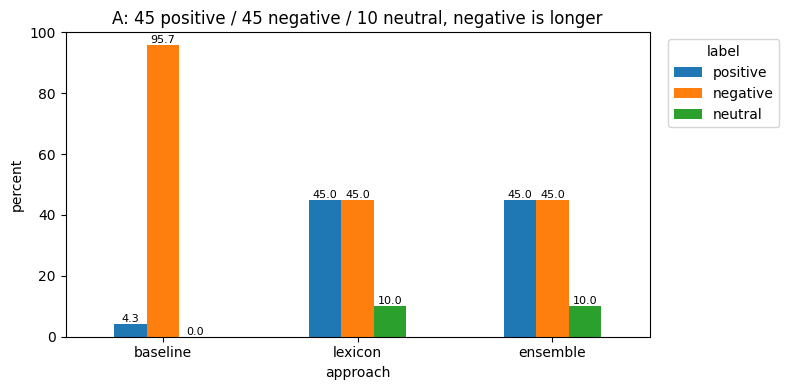

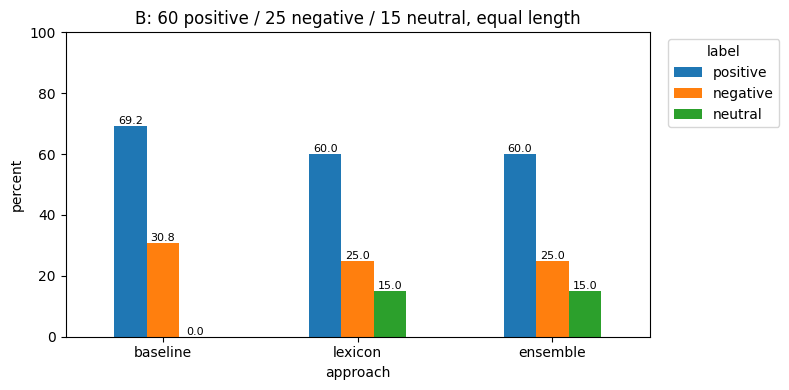

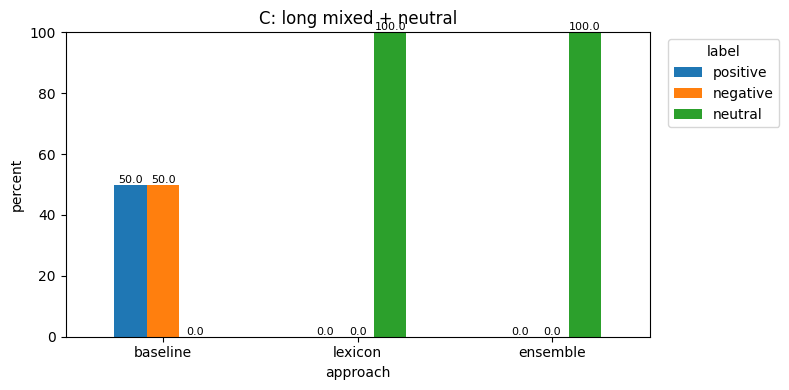

In [22]:
if plt is None:
    print('matplotlib не установлен, график пропущен')
else:
    metrics = ['positive', 'negative', 'neutral']
    approach_order = ['baseline', 'lexicon', 'ensemble']

    for scenario_name, scenario_df in comparison.groupby('scenario', sort=False):
        plot_data = (
            scenario_df
            .set_index('approach')[metrics]
            .reindex(approach_order)
        )

        ax = plot_data.plot(kind='bar', figsize=(8, 4), ylim=(0, 100))
        ax.set_title(scenario_name)
        ax.set_xlabel('approach')
        ax.set_ylabel('percent')
        ax.legend(title='label', bbox_to_anchor=(1.02, 1), loc='upper left')

        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f', fontsize=8)

        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()


## Sensitivity

Фиксируем `45 positive / 45 negative / 10 neutral`, но постепенно удлиняем negative-отзывы.

In [23]:
sensitivity = make_sensitivity_table(client=None)
display(sensitivity)

,scenario,negative_length_multiplier,approach,positive,negative,neutral,positive_count,negative_count,neutral_count,llm_used,fallback_count
0,negative length x1,1,baseline,25.9,74.1,0.0,NaN,NaN,NaN,0,0
1,negative length x1,1,lexicon,45.0,45.0,10.0,45.0,45.0,10.0,0,0
2,negative length x1,1,ensemble,45.0,45.0,10.0,45.0,45.0,10.0,0,55
3,negative length x2,2,baseline,15.0,85.0,0.0,NaN,NaN,NaN,0,0
4,negative length x2,2,lexicon,45.0,45.0,10.0,45.0,45.0,10.0,0,0
5,negative length x2,2,ensemble,45.0,45.0,10.0,45.0,45.0,10.0,0,55
6,negative length x4,4,baseline,8.2,91.8,0.0,NaN,NaN,NaN,0,0
7,negative length x4,4,lexicon,45.0,45.0,10.0,45.0,45.0,10.0,0,0
8,negative length x4,4,ensemble,45.0,45.0,10.0,45.0,45.0,10.0,0,55
9,negative length x8,8,baseline,4.3,95.7,0.0,NaN,NaN,NaN,0,0


## График sensitivity

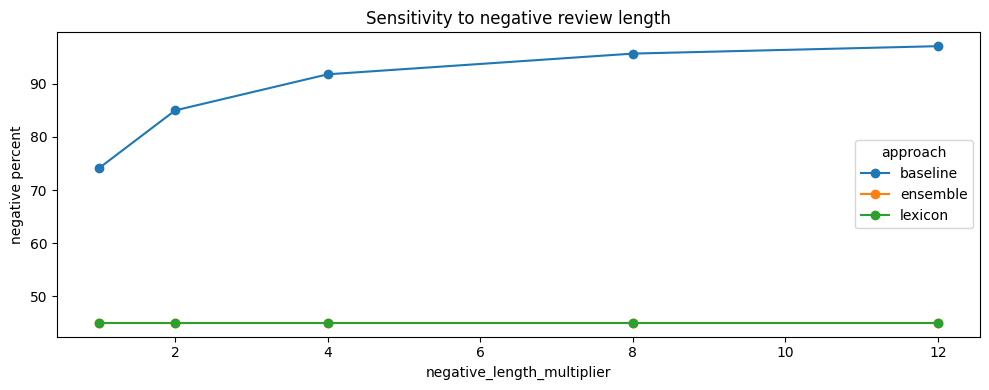

In [24]:
if plt is None:
    print('matplotlib не установлен, график пропущен')
else:
    sensitivity_plot = sensitivity.pivot_table(
        index='negative_length_multiplier',
        columns='approach',
        values='negative',
        aggfunc='first',
    )
    ax = sensitivity_plot.plot(marker='o', figsize=(10, 4))
    ax.set_ylabel('negative percent')
    ax.set_title('Sensitivity to negative review length')
    plt.tight_layout()
    plt.show()

## Edge cases

In [25]:
edge_reviews = [
    'Норм',
    'Спасибо',
    '5/5',
    'Хороший преподаватель, всё понятно',
    ('Курс ужасный, непонятный, перегруженный и плохо организованный. ' * 40),
    'Лекции интересные, но домашка убивает',
    "Ну да, конечно, 'отличная' организация курса",
    'Great useful and clear course',
    'The course was boring and confusing',
    '',
    '.',
    '🤖',
    '🙂',
    '😢',
]

edge_table = pd.DataFrame({
    'review': edge_reviews,
    'lexicon_label': [classify_review(review) for review in edge_reviews],
    'ensemble_label': [classify_review_ensemble(review)[0] for review in edge_reviews],
    'needs_llm': [needs_llm_review(review) for review in edge_reviews],
})
display(edge_table)

,review,lexicon_label,ensemble_label,needs_llm
0,Норм,neutral,neutral,True
1,Спасибо,positive,positive,True
2,5/5,positive,positive,True
3,"Хороший преподаватель, всё понятно",positive,positive,True
4,"Курс ужасный, непонятный, перегруженный и плох...",negative,negative,True
5,"Лекции интересные, но домашка убивает",neutral,neutral,True
6,"Ну да, конечно, 'отличная' организация курса",positive,positive,True
7,Great useful and clear course,positive,positive,True
8,The course was boring and confusing,negative,negative,True
9,,None,None,False


## Optional Groq LLM — запуск настоящей LLM

Эта ячейка запускает реальную LLM через Groq API только на маленьком наборе отзывов, чтобы не тратить лимиты. Ключ не нужно писать в коде: ячейка попросит `GROQ_API_KEY` через `getpass`.

Важно: без API-ключа notebook всё равно работает, просто ensemble использует lexicon fallback.


In [26]:
from getpass import getpass

llm_reviews = [
    'Лекции интересные, но домашка слишком тяжелая',
    "Ну да, конечно, 'отличная' организация: дедлайны менялись каждый день",
    'Not bad, the lectures were useful',
    'The lectures were clear and useful, but the workload was too heavy.',
]

if not os.environ.get('GROQ_API_KEY'):
    try:
        os.environ['GROQ_API_KEY'] = getpass('Введите GROQ_API_KEY, если хотите вызвать настоящую LLM: ').strip()
    except Exception:
        pass

if os.environ.get('GROQ_API_KEY'):
    client = create_groq_client()

    rows = []
    for review in llm_reviews:
        lexicon_label = classify_review(review)
        label, meta = classify_review_ensemble(review, client=client)

        rows.append({
            'review': review,
            'lexicon_label': lexicon_label,
            'ensemble_label': label,
            'source': meta.get('source'),
            'llm_used': meta.get('llm_used'),
            'fallback': meta.get('fallback'),
        })

    display(pd.DataFrame(rows))
else:
    print('GROQ_API_KEY не задан. LLM-вызовы пропущены, notebook можно запускать без API.')


Введите GROQ_API_KEY, если хотите вызвать настоящую LLM: ··········


,review,lexicon_label,ensemble_label,source,llm_used,fallback
0,"Лекции интересные, но домашка слишком тяжелая",neutral,neutral,llm,True,False
1,"Ну да, конечно, 'отличная' организация: дедлай...",positive,negative,llm,True,False
2,"Not bad, the lectures were useful",positive,positive,llm,True,False
3,"The lectures were clear and useful, but the wo...",positive,neutral,llm,True,False


## Optional Groq LLM на всех сценариях

По умолчанию полный прогон выключен, потому что он делает больше API-вызовов. Чтобы запустить LLM на сценариях A/B/C, поменяйте `RUN_FULL_LLM_COMPARISON = False` на `True`.


In [27]:
RUN_FULL_LLM_COMPARISON = True

if RUN_FULL_LLM_COMPARISON:
    client = create_groq_client()
    comparison_llm = compare_scenarios(client=client)
    display(comparison_llm)
else:
    print('Полный LLM-прогон выключен. Чтобы запустить, поставьте RUN_FULL_LLM_COMPARISON = True.')


Полный LLM-прогон выключен. Чтобы запустить, поставьте RUN_FULL_LLM_COMPARISON = True.


## JSON test report

Те же 20 проверок, что и в проекте: 10 для lexicon и 10 для ensemble. Результат сохраняется в `test_results.json`.

In [28]:
class FakeMessage:
    def __init__(self, content):
        self.content = content


class FakeChoice:
    def __init__(self, content):
        self.message = FakeMessage(content)


class FakeResponse:
    def __init__(self, content):
        self.choices = [FakeChoice(content)]


class FakeCompletions:
    def __init__(self, content):
        self.content = content
        self.calls = 0

    def create(self, **kwargs):
        self.calls += 1
        return FakeResponse(self.content)


class FakeChat:
    def __init__(self, completions):
        self.completions = completions


class FakeClient:
    def __init__(self, content):
        self.completions = FakeCompletions(content)
        self.chat = FakeChat(self.completions)


def run_check(name, function):
    try:
        function()
        return {"name": name, "status": "passed", "error": None}
    except Exception as error:
        return {"name": name, "status": "failed", "error": str(error)}


def lexicon_checks():
    positive = "Отличный курс, все понятно и полезно"
    negative = ("Курс ужасный непонятный сложный тяжелый перегруженный неудобный скучный плохой проблемный ") * 8
    neutral = "Обычный курс без сильных плюсов и минусов"
    return [
        ("empty_list", lambda: analyze_reviews([])["distribution"] == {"positive": 0.0, "negative": 0.0, "neutral": 0.0} or (_ for _ in ()).throw(AssertionError())),
        ("garbage", lambda: analyze_reviews(["", ".", "a", "🤖"])["review_count"] == 0 or (_ for _ in ()).throw(AssertionError())),
        ("short_positive", lambda: classify_review("Хороший преподаватель, всё понятно") == "positive" or (_ for _ in ()).throw(AssertionError())),
        ("short_negative", lambda: classify_review("Плохой непонятный курс") == "negative" or (_ for _ in ()).throw(AssertionError())),
        ("neutral", lambda: classify_review(neutral) == "neutral" or (_ for _ in ()).throw(AssertionError())),
        ("mixed", lambda: classify_review("Лекции интересные, но домашка убивает") == "neutral" or (_ for _ in ()).throw(AssertionError())),
        ("english", lambda: (classify_review("Great useful and clear course"), classify_review("The course was boring and confusing")) == ("positive", "negative") or (_ for _ in ()).throw(AssertionError())),
        ("negations", lambda: (classify_review("не плохо"), classify_review("не понравилось"), classify_review("not bad"), classify_review("not useful")) == ("positive", "negative", "positive", "negative") or (_ for _ in ()).throw(AssertionError())),
        ("ratings_emojis", lambda: (classify_review("5/5"), classify_review("1/5"), classify_review("🙂"), classify_review("😢")) == ("positive", "negative", "positive", "negative") or (_ for _ in ()).throw(AssertionError())),
        ("balance", lambda: improved_distribution([positive] * 45 + [negative] * 45 + [neutral] * 10)[1] == {"positive": 45, "negative": 45, "neutral": 10} or (_ for _ in ()).throw(AssertionError())),
    ]


def ensemble_checks():
    positive = "Отличный курс, все понятно и полезно"
    negative = ("Курс ужасный непонятный сложный тяжелый перегруженный неудобный скучный плохой проблемный ") * 8
    neutral = "Обычный курс без сильных плюсов и минусов"
    fake = FakeClient('{"label": "negative", "confidence": 0.9, "flags": ["sarcasm"]}')
    return [
        ("empty_list", lambda: analyze_reviews_ensemble([])["distribution"] == {"positive": 0.0, "negative": 0.0, "neutral": 0.0} or (_ for _ in ()).throw(AssertionError())),
        ("garbage", lambda: analyze_reviews_ensemble(["", ".", "a", "🤖"])["label_counts"] == {"positive": 0, "negative": 0, "neutral": 0} or (_ for _ in ()).throw(AssertionError())),
        ("short_positive", lambda: classify_review_ensemble("Хороший преподаватель, всё понятно")[0] == "positive" or (_ for _ in ()).throw(AssertionError())),
        ("short_negative", lambda: classify_review_ensemble("Плохой непонятный курс")[0] == "negative" or (_ for _ in ()).throw(AssertionError())),
        ("neutral", lambda: classify_review_ensemble(neutral)[0] == "neutral" or (_ for _ in ()).throw(AssertionError())),
        ("mixed_sarcasm", lambda: (classify_review_ensemble("Лекции интересные, но домашка убивает")[0], classify_review_ensemble("Ну да, конечно, 'отличная' организация курса", client=fake)[0]) == ("neutral", "negative") or (_ for _ in ()).throw(AssertionError())),
        ("english", lambda: (classify_review_ensemble("Great useful and clear course")[0], classify_review_ensemble("The course was boring and confusing")[0]) == ("positive", "negative") or (_ for _ in ()).throw(AssertionError())),
        ("negations", lambda: (classify_review_ensemble("не плохо")[0], classify_review_ensemble("не понравилось")[0], classify_review_ensemble("not bad")[0], classify_review_ensemble("not useful")[0]) == ("positive", "negative", "positive", "negative") or (_ for _ in ()).throw(AssertionError())),
        ("ratings_emojis", lambda: (classify_review_ensemble("5/5")[0], classify_review_ensemble("1/5")[0], classify_review_ensemble("🙂")[0], classify_review_ensemble("😢")[0]) == ("positive", "negative", "positive", "negative") or (_ for _ in ()).throw(AssertionError())),
        ("balance", lambda: ensemble_distribution([positive] * 45 + [negative] * 45 + [neutral] * 10)["label_counts"] == {"positive": 45, "negative": 45, "neutral": 10} or (_ for _ in ()).throw(AssertionError())),
    ]


report = {"summary": {"total": 0, "passed": 0, "failed": 0}, "approaches": {}}
for approach, checks in {"lexicon": lexicon_checks(), "ensemble": ensemble_checks()}.items():
    tests = [run_check(name, function) for name, function in checks]
    passed = sum(test["status"] == "passed" for test in tests)
    failed = sum(test["status"] == "failed" for test in tests)
    report["approaches"][approach] = {"passed": passed, "failed": failed, "tests": tests}
report["summary"]["total"] = sum(result["passed"] + result["failed"] for result in report["approaches"].values())
report["summary"]["passed"] = sum(result["passed"] for result in report["approaches"].values())
report["summary"]["failed"] = sum(result["failed"] for result in report["approaches"].values())
Path('test_results.json').write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding='utf-8')
display(pd.DataFrame([report['summary']]))

,total,passed,failed
0,20,20,0


## Вывод

Baseline зависит от объёма sentiment-слов, поэтому длинные negative-отзывы перетягивают итог. Lexicon и ensemble работают на уровне отдельных отзывов, поэтому распределение остаётся близким к реальному количеству отзывов. LLM-часть является бонусом: она помогает на сложных mixed/sarcasm/English кейсах, но проект воспроизводим и без API-ключа.